In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F #moves data forward in function
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [5]:
# Create Model Class that inherits nn.Module
class Model(nn.Module): #class = neural network, doing nn.Module means it is able to use all of these features
    #input layer with 4 features --> hidden layer 1 --> hidden layer 2 --> single output
    def __init__(self, in_features=5, h1=64, h2=32, out_features=1): #creates layers
        super().__init__() #sets up parent class initialisation of nn.Module
        self.fc1 = nn.Linear(in_features, h1) #creating hidden layer 1 here with in_features number of inputs and h1 number of outputs
        self.fc2 = nn.Linear(h1,h2) 
        self.out = nn.Linear(h2,out_features) #even for nonlinear datasets, nn.Linear is the choice here, just need to add activation later
    def forward(self,x): #function which moves data through network, x is the variable here which gets moved through
        x = F.relu(self.fc1(x)) #Activation ReLU function (Rectified Linear Unit)
        x = F.relu(self.fc2(x)) 
        x = self.out(x) #No activation function on final layer
        return x

In [6]:
torch.manual_seed(10)
model = Model().to(device) #create model

In [7]:
import pandas as pd
import os
data_path = r"C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\y3 individual project\Sample Data 2D - Stoichiometric (2)"
all_data = []

for i in range(10000, 10200):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows

    #read field data
    for t in range(2, 16):  # time snapshots (14 with active chemistry)
        fields_df = pd.read_csv(os.path.join(data_path, f'fields_{i}_{t}'),
                               sep=r'\s+', skiprows=5, header=None,
                               names=['density', 'u', 'v', 'vorticity', 'temperature',
                                      'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4',
                                      'ms5', 'ms6', 'ms7', 'ms8', 'ms9','c','dc/dx','dc/dy'])
        
        combined = pd.concat([nodes_df, fields_df], axis=1)
        combined['processor'] = i
        combined['timestep'] = t 
        all_data.append(combined)

# Final DataFrame with everything
df = pd.concat(all_data, ignore_index=True) #vertical merger of all processor data into a single data frame, pd.concat default is vertical so no spec needed

print(f" Final shape: {df.shape}")
df

 Final shape: (1909670, 28)


,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms5,ms6,ms7,ms8,ms9,c,dc/dx,dc/dy,processor,timestep
0,2328,-1.921960,0.447463,0.006,0.015876,0.015876,999,0.845151,1.646973,-0.001170,...,-2.081730e-29,-1.706650e-27,5.670292e-26,-1.045044e-41,0.745187,0.027933,8.301732e-06,7.146258e-06,10000,2
1,4233,-1.853835,0.447651,0.006,0.016200,0.016200,999,0.845138,1.639752,-0.000348,...,-3.781888e-29,-3.017999e-27,1.032569e-25,1.862424e-38,0.745187,0.027933,4.862421e-07,1.966991e-06,10000,2
2,6482,-1.775918,0.447719,0.006,0.015247,0.015247,999,0.845127,1.631904,-0.000008,...,-4.898227e-29,-3.898029e-27,1.339446e-25,9.291338e-38,0.745187,0.027933,7.598729e-06,-1.021200e-05,10000,2
3,6125,-1.787625,0.447738,0.006,0.015876,0.015876,999,0.845127,1.632888,0.000087,...,-4.848529e-29,-3.824818e-27,1.329545e-25,-2.506693e-37,0.745187,0.027933,3.392028e-06,-1.156857e-05,10000,2
4,4433,-1.845683,0.447841,0.006,0.016200,0.016200,999,0.845137,1.638664,-0.000313,...,-3.975168e-29,-3.151244e-27,1.087707e-25,-6.994422e-39,0.745187,0.027933,6.917993e-06,5.534105e-07,10000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1909665,132345,1.860804,0.447907,0.006,0.015876,0.015876,999,0.122271,28.653734,0.152338,...,5.247480e-03,7.402413e-05,1.966674e-06,1.949610e-07,0.745443,0.959333,2.295616e-01,-4.761958e-03,10199,15
1909666,132187,1.853980,0.448018,0.006,0.015876,0.015876,999,0.122272,28.653512,0.170402,...,5.245474e-03,7.402680e-05,1.964870e-06,1.948266e-07,0.745456,0.959317,2.318928e-01,-8.613402e-03,10199,15
1909667,131611,1.834425,0.448094,0.006,0.013507,0.013507,999,0.122273,28.654256,0.221284,...,5.239488e-03,7.403301e-05,1.959528e-06,1.944327e-07,0.745493,0.959271,2.355448e-01,-2.274977e-02,10199,15
1909668,130933,1.810192,0.448103,0.006,0.015876,0.015876,999,0.122276,28.654298,0.280889,...,5.232222e-03,7.404338e-05,1.953010e-06,1.939597e-07,0.745537,0.959214,2.344067e-01,-4.136717e-02,10199,15


In [8]:
#Reducing DF to region of significant chemistry
df_filtered = df[df['c'].between(0.1, 0.9)]
df_filtered = df_filtered[df_filtered['HRR'] >= 0]
df_filtered

,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms5,ms6,ms7,ms8,ms9,c,dc/dx,dc/dy,processor,timestep
8294,6482,-1.775918,0.447719,0.006000,0.015247,0.015247,999,0.154419,9.407182,-2.248900,...,0.009633,0.001276,0.000010,0.000008,0.744298,0.872224,60.485072,-52.324829,10000,14
8295,6125,-1.787625,0.447738,0.006000,0.015876,0.015876,999,0.162006,8.231564,-1.724866,...,0.009002,0.001516,0.000016,0.000012,0.742868,0.868180,47.707432,-34.456465,10000,14
8299,6815,-1.762082,0.448867,0.006000,0.015558,0.015558,999,0.148997,10.714804,-3.702798,...,0.010152,0.001081,0.000009,0.000006,0.744238,0.881034,56.339134,-47.171756,10000,14
8306,5405,-1.811426,0.449030,0.006000,0.014064,0.014064,999,0.257742,7.443067,-2.038174,...,0.001663,0.000871,0.000152,0.000039,0.733295,0.547659,2733.837863,-2063.767978,10000,14
8307,6650,-1.768423,0.449321,0.006000,0.015876,0.015876,999,0.151654,10.153175,-3.006802,...,0.009850,0.001174,0.000009,0.000007,0.744356,0.876530,75.349889,-61.089452,10000,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1221348,82110,0.221866,0.328085,0.004064,0.010537,0.010537,999,0.132559,19.429950,-1.834770,...,0.009379,0.000493,0.000004,0.000002,0.747414,0.898681,29.688642,24.324187,10128,2
1221370,81873,0.218792,0.330342,0.004039,0.010474,0.010474,999,0.132990,19.248273,-1.938820,...,0.009452,0.000506,0.000004,0.000002,0.747316,0.898300,31.000959,24.606059,10128,2
1221384,82100,0.221916,0.332975,0.004063,0.010750,0.010750,999,0.133332,19.169912,-1.890431,...,0.009472,0.000502,0.000004,0.000002,0.747081,0.899951,31.087443,26.999947,10128,2
1221397,81885,0.217487,0.334626,0.004041,0.009664,0.009664,999,0.133741,18.987279,-2.025378,...,0.009546,0.000518,0.000004,0.000002,0.747044,0.898979,32.765834,26.492270,10128,2


In [9]:
#step 2 - specifying variables of interest
#For this basic model, 6 inputs, 1 output
model_variables = ['c','density','temperature','dc/dx','dc/dy','HRR']
model_data = df_filtered[model_variables]

print(model_data)

X=model_data[['c','density','temperature','dc/dx','dc/dy']].values
y=model_data['HRR'].values

                c   density  temperature        dc/dx        dc/dy  \
8294     0.872224  0.154419  1815.550685    60.485072   -52.324829   
8295     0.868180  0.162006  1722.813462    47.707432   -34.456465   
8299     0.881034  0.148997  1891.716626    56.339134   -47.171756   
8306     0.547659  0.257742  1061.552357  2733.837863 -2063.767978   
8307     0.876530  0.151654  1854.105857    75.349889   -61.089452   
...           ...       ...          ...          ...          ...   
1221348  0.898681  0.132559  2156.817340    29.688642    24.324187   
1221370  0.898300  0.132990  2149.338331    31.000959    24.606059   
1221384  0.899951  0.133332  2145.384287    31.087443    26.999947   
1221397  0.898979  0.133741  2137.747806    32.765834    26.492270   
1221428  0.899971  0.134566  2125.434441    34.526755    28.644640   

                  HRR  
8294     3.396895e+09  
8295     5.227442e+09  
8299     2.287389e+09  
8306     1.413351e+10  
8307     2.694053e+09  
...            

In [10]:
from sklearn.model_selection import train_test_split
X_train_unscaled, X_unseen_unscaled, y_train_unscaled, y_unseen_unscaled = train_test_split(X,y,test_size=0.2,random_state=10) #must s
X_test_unscaled, X_val_unscaled, y_test_unscaled, y_val_unscaled = train_test_split(X_unseen_unscaled,y_unseen_unscaled,test_size=0.5,random_state=10)

#scale data
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_unscaled) #apply normalisation
X_val = scaler_X.transform(X_val_unscaled)   
X_test = scaler_X.transform(X_test_unscaled)        

y_train_log = np.log1p(np.abs(y_train_unscaled))
y_val_log = np.log1p(np.abs(y_val_unscaled))
y_test_log = np.log1p(np.abs(y_test_unscaled))    
y_train = scaler_y.fit_transform(y_train_log.reshape(-1, 1))
y_val = scaler_y.transform(y_val_log.reshape(-1, 1))
y_test = scaler_y.transform(y_test_log.reshape(-1, 1))   

#convert numpy arrays into tensors for use in PyTorch
X_train = torch.FloatTensor(X_train).to(device) #for floats
X_val = torch.FloatTensor(X_val).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).view(-1,1).to(device) #reshape
y_val = torch.FloatTensor(y_val).view(-1,1).to(device)
y_test = torch.FloatTensor(y_test).view(-1,1).to(device) #.to(device) moves to GPU 

In [11]:
#batch training
from torch.utils.data import DataLoader, TensorDataset
batch_size=32768
dataset=TensorDataset(X_train,y_train) 
train_loader=DataLoader(dataset,batch_size=batch_size,shuffle=True)#shuffle improves generalisation performance

In [12]:
from codecarbon import EmissionsTracker #carbon emission tracker
import time

tracker = EmissionsTracker()
tracker.start()
start_training=time.time()

[codecarbon WARNING @ 00:53:04] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 00:53:05] [setup] RAM Tracking...
[codecarbon INFO @ 00:53:05] [setup] CPU Tracking...
[codecarbon WARNING @ 00:53:07] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 00:53:07] CPU Model on constant consumption mode: 12th Gen Intel(R) Core(TM) i7-12700H
[codecarbon WARNING @ 00:53:07] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 00:53:07] [setup] GPU Tracking...
[codecarbon INFO @ 00:53:07] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 00:53:07] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 00:53:07] >>> Tracker's metadata:
[code

In [13]:
torch.manual_seed(10)
model=Model().to(device)
criterion = nn.MSELoss() #Mean Squared Error for regression
optimiser = torch.optim.Adam(model.parameters(),lr=0.001) #choose optimiser and learning rate, model parameters are the layers

In [14]:
epochs=400
train_losses=[] #list which will be added to
val_losses=[]

# Early stopping setup
best_val_loss = float('inf')
patience_counter = 0
patience = 30
min_improvement = 0.02  # 2% minimum improvement
for i in range(epochs):
    model.train() #training mode
    batch_losses=[]
    for X_batch,y_batch in train_loader:
        optimiser.zero_grad() #resets gradient calculation (neccesary)
        #go forward and predict
        y_pred=model.forward(X_batch) #get predicted results
        #Measure loss
        loss = criterion(y_pred,y_batch)
        #Back propagation (fine tuning of neuron parameters)
        loss.backward() #works out gradient for each weight (how much each weight contributed to error)
        optimiser.step() #gradient descent to update weight based on optimiser (optimiser determines how much to change weight by)
        batch_losses.append(loss.item())
        
    train_loss=np.mean(batch_losses)
    train_losses.append(train_loss)

    #validation
    model.eval()  # evaluation mode
    with torch.no_grad():  # No gradient computation for validation
        y_val_pred = model.forward(X_val)
        val_loss = criterion(y_val_pred, y_val)
        val_losses.append(val_loss.detach().cpu().numpy())

    # Early stopping check
    if val_loss < best_val_loss * (1 - min_improvement):
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {i}, best val loss: {best_val_loss:.5f}")
        break
        
    #print every 50 epochs
    if i % 5 == 0: #% operator gives remainder 
        print(f'Epoch:{i}, Training loss: {train_loss}, Validation Loss: {val_loss}')

model.load_state_dict(torch.load('best_model.pt',weights_only=True))
print("Best model loaded")

Epoch:0, Training loss: 1.0875020424524944, Validation Loss: 1.0049140453338623
Epoch:5, Training loss: 0.7062100569407145, Validation Loss: 0.6626033186912537


[codecarbon INFO @ 00:53:27] Energy consumed for RAM : 0.000090 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:53:27] Delta energy consumed for CPU with cpu_load : 0.000024 kWh, power : 5.3039232693 W
[codecarbon INFO @ 00:53:28] Energy consumed for All CPU : 0.000024 kWh
[codecarbon INFO @ 00:53:28] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 00:53:28] Energy consumed for all GPUs : 0.000056 kWh. Total GPU Power : 11.856174393626416 W
[codecarbon INFO @ 00:53:28] 0.000170 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch:10, Training loss: 0.47411273916562396, Validation Loss: 0.44250988960266113


[codecarbon INFO @ 00:53:42] Energy consumed for RAM : 0.000169 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:53:42] Delta energy consumed for CPU with cpu_load : 0.000021 kWh, power : 5.3965066311 W
[codecarbon INFO @ 00:53:42] Energy consumed for All CPU : 0.000046 kWh
[codecarbon INFO @ 00:53:42] Energy consumed for all GPUs : 0.000109 kWh. Total GPU Power : 12.875010591905184 W
[codecarbon INFO @ 00:53:42] 0.000324 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch:15, Training loss: 0.28454359372456867, Validation Loss: 0.2636633515357971
Epoch:20, Training loss: 0.1691527913014094, Validation Loss: 0.15482720732688904


...

Epoch:170, Training loss: 0.01866877016921838, Validation Loss: 0.01733403280377388
Epoch:175, Training loss: 0.018658891320228577, Validation Loss: 0.017296886071562767


[codecarbon INFO @ 00:58:43] Energy consumed for RAM : 0.001749 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:58:43] Delta energy consumed for CPU with cpu_load : 0.000021 kWh, power : 5.1875050257 W
[codecarbon INFO @ 00:58:44] Energy consumed for All CPU : 0.000487 kWh
[codecarbon INFO @ 00:58:44] Energy consumed for all GPUs : 0.001210 kWh. Total GPU Power : 13.070331166704248 W
[codecarbon INFO @ 00:58:44] 0.003446 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch:180, Training loss: 0.018703268220027287, Validation Loss: 0.01723615825176239
Epoch:185, Training loss: 0.018286799391110737, Validation Loss: 0.01718463934957981


[codecarbon INFO @ 00:58:58] Energy consumed for RAM : 0.001828 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:58:59] Delta energy consumed for CPU with cpu_load : 0.000020 kWh, power : 5.026794169218751 W
[codecarbon INFO @ 00:58:59] Energy consumed for All CPU : 0.000507 kWh
[codecarbon INFO @ 00:58:59] Energy consumed for all GPUs : 0.001263 kWh. Total GPU Power : 13.07130943342921 W
[codecarbon INFO @ 00:58:59] 0.003598 kWh of electricity and 0.000000 L of water were used since the beginning.


Early stopping at epoch 189, best val loss: 0.01748
Best model loaded


In [15]:
training_time=time.time()-start_training
print(f"Training time: {training_time} secs")

training_emissions=tracker.stop()
print(f"Training Emissions: {training_emissions} kg CO2")

[codecarbon INFO @ 00:59:05] Energy consumed for RAM : 0.001863 kWh. RAM Power : 20.0 W


Training time: 353.2882981300354 secs


[codecarbon INFO @ 00:59:05] Delta energy consumed for CPU with cpu_load : 0.000009 kWh, power : 5.032291123928573 W
[codecarbon INFO @ 00:59:05] Energy consumed for All CPU : 0.000516 kWh
[codecarbon INFO @ 00:59:05] Energy consumed for all GPUs : 0.001288 kWh. Total GPU Power : 13.106208135993553 W
[codecarbon INFO @ 00:59:05] 0.003667 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 00:59:05] 0.002438 g.CO2eq/s mean an estimation of 76.89545463601576 kg.CO2eq/year


Training Emissions: 0.0008712344976053916 kg CO2


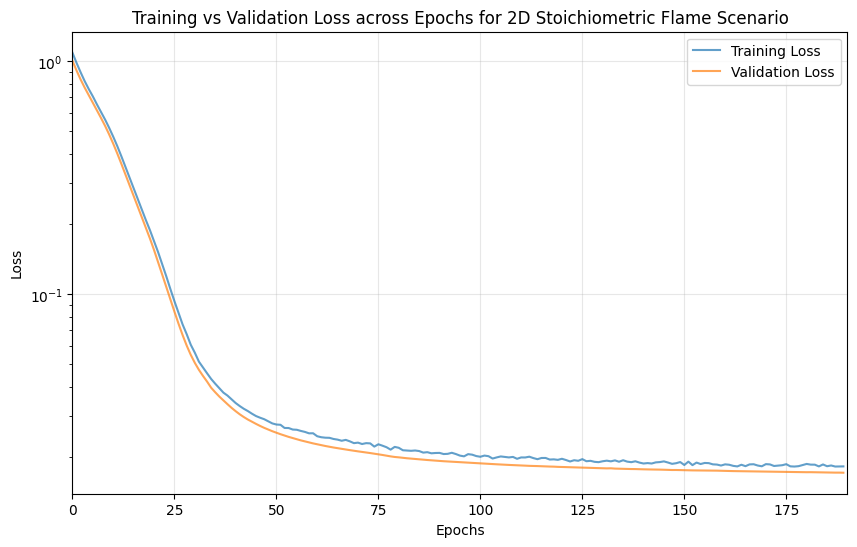

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', alpha=0.7)
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xlim(0,len(train_losses))
plt.title('Training vs Validation Loss across Epochs for 2D Stoichiometric Flame Scenario')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
tracker.start()
start_inference=time.time()

[codecarbon WARNING @ 00:59:07] Already started tracking


In [18]:
#Evaluate Model
with torch.no_grad():
    y_pred_scaled = model(X_test)
    
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy().reshape(-1, 1))
    y_test_log = scaler_y.inverse_transform(y_test.cpu().numpy().reshape(-1, 1))

    y_pred_actual = np.sign(y_pred_log) * np.expm1(np.abs(y_pred_log))
    y_test_actual = np.sign(y_test_log) * np.expm1(np.abs(y_test_log))

In [19]:
inference_time=time.time()-start_inference
print(f"Inference time: {inference_time} secs, Inference time per sample: {inference_time/len(X_test)*1000:.4f}ms")

Inference time: 0.036582231521606445 secs, Inference time per sample: 0.0034ms


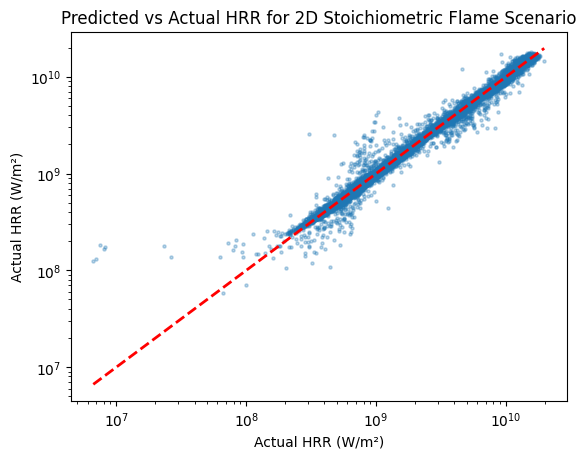

In [20]:
y_pred_np = y_pred_actual.flatten()
y_test_np = y_test_actual.flatten()

plt.scatter(y_test_np,y_pred_np,alpha=0.3, s=5)
plt.title("Predicted vs Actual HRR for 2D Stoichiometric Flame Scenario")
plt.xlabel('Actual HRR (W/m²)')
plt.ylabel('Actual HRR (W/m²)')
plt.yscale('log')
plt.xscale('log')
plt.plot([y_test_np.min(), y_test_np.max()],   
         [y_test_np.min(), y_test_np.max()],   
         'r--', lw=2)
plt.show()

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

r2 = r2_score(y_test_np, y_pred_np)
mae = mean_absolute_error(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100
nmse = mean_squared_error(y_test_np, y_pred_np)/np.var(y_test_np)

#new metric - normalised MSE


print(f"\nR² Score: {r2:.4f}")
print(f"MAE:      {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")  
print(f"NMSE: {nmse:.5f}") 


R² Score: 0.9826
MAE:      271056544.00
RMSE:     560984056.33
MAPE: 8.56%
NMSE: 0.01741
